# Horn genome chromosome context/landscape plot

Per-chromosome tracks for the **final de-novo assembly** `10-horn-final.renamed.fa`:

- **GenMap mappability** (green, 0–1)
- **TRF tandem-repeat fraction** (blue)
- **RepeatOBserver Shannon diversity** (purple, min-max normalised)
- **nanopore coverage** (brown; 0.5 = genome-median depth)
- **LAI** (orange, right twin axis, real units — LTR_retriever 3 Mb windows)
- **v2r hits**: from curation pipeline (col: ['coverage_class' == (intact = red) | (fragmented|pseudogene = blue)])


In [14]:
%matplotlib inline
import numpy as np, matplotlib, glob
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

def resolve(path):
    """Return path if it exists, else search by basename under its top dir (dir keeps moving)."""
    import os
    if os.path.exists(path): return path
    base = os.path.basename(path)
    for root in ("/hpcfs/users/a1864358/sanders_lab/asm/files/annotation", os.path.dirname(path)):
        hits = glob.glob(f"{root}/**/{base}", recursive=True)
        if hits: return hits[0]
    return path

def resolve(path):
    """Return path if it exists, else search by basename under its top dir (dir keeps moving)."""
    import os
    if os.path.exists(path): return path
    base = os.path.basename(path)
    for root in ("/hpcfs/users/a1864358/sanders_lab/asm/files/annotation", os.path.dirname(path)):
        hits = glob.glob(f"{root}/**/{base}", recursive=True)
        if hits: return hits[0]
    return path


In [15]:
BIN = 1_000_000 # try 500_000 after
CHROMS = ["ch1","ch2","ch3","ch4","ch5","ch7","ch8","chZ"]
FAI = "/hpcfs/users/a1864358/sanders_lab/resources/final-asms/10-horn-final.renamed.fa.fai"
TRF = "/hpcfs/users/a1864358/sanders_lab/asm/files/tandem-repeat-anal/genome-context/trf_horn/horn.trf.ngs.dat"
MAP = "/hpcfs/users/a1864358/sanders_lab/asm/files/repeat-anno/ra2/results/07_comparative/genmap/horn/mappability.1Mb.tsv"
SHA = "/hpcfs/users/a1864358/sanders_lab/asm/files/tandem-repeat-anal/robserver_horn_shannon.tsv"
LAI = "/hpcfs/users/a1864358/sanders_lab/asm/files/repeat-anno/ra2/results/05_LAI/final/10-horn-final.renamed.fa.hybridlib.out.LAI"
V2R_GENES = "/hpcfs/users/a1864358/sanders_lab/asm/files/annotation/eviann_results/hmaj/curation/results/horn/v2r_genes.tsv"
COV = "/hpcfs/users/a1864358/sanders_lab/asm/files/tandem-repeat-anal/horn_cov.1Mb.tsv"


## Chromosome lengths + TRF tandem-repeat coverage (per 1 Mb)


In [16]:
length = {}
for ln in open(FAI):
    f = ln.split("\t"); length[f[0]] = int(f[1])
nbins = {c: length[c]//BIN + 1 for c in CHROMS}

# RF coverage (merged) per 1Mb
ivals = {c: [] for c in CHROMS}; cur = None
for line in open(TRF):
    if line[0] == "@": cur = line[1:].strip(); continue
    if cur not in ivals: continue
    p = line.split(); s, e = int(p[0]), int(p[1])
    if e < s: s, e = e, s
    ivals[cur].append((s, e))
    
def cov_track(iv, glen):
    out = np.zeros(glen//BIN + 1)
    if not iv: return out
    iv = sorted(iv); cs, ce = iv[0]; merged = []
    for s, e in iv[1:]:
        if s <= ce+1: ce = max(ce, e)
        else: merged.append((cs, ce)); cs, ce = s, e
    merged.append((cs, ce))
    for s, e in merged:
        for b in range(s//BIN, e//BIN + 1):
            lo = max(s, b*BIN); hi = min(e, (b+1)*BIN - 1); out[b] += hi-lo+1
    return out
trf = {c: 100.0*cov_track(ivals[c], length[c])/BIN for c in CHROMS}


## GenMap mappability (mean per 1 Mb)


In [17]:
# GenMap mean mappability per 1Mb
mapp = {c: np.full(nbins[c], np.nan) for c in CHROMS}
for ln in open(MAP):
    c, b, v, cov = ln.split("\t")
    if c in mapp and int(b) < nbins[c]:
        mapp[c][int(b)] = float(v)


## RepeatOBserver Shannon diversity (mean per 1 Mb)


In [18]:
# RepeatOBserver Shannon: mean per 1Mb
ssum = {c: np.zeros(nbins[c]) for c in CHROMS}
scnt = {c: np.zeros(nbins[c]) for c in CHROMS}
hdr = True
for ln in open(SHA):
    if hdr: hdr = False; continue
    c, pos, h = ln.split("\t")
    if c in ssum:
        b = int(pos)//BIN
        if b < nbins[c]: ssum[c][b] += float(h); scnt[c][b] += 1
sha = {c: np.divide(ssum[c], scnt[c], out=np.full(nbins[c], np.nan), where=scnt[c]>0) for c in CHROMS}


## LAI per sliding window (LTR_retriever)


In [19]:
# LAI per sliding window
lai_x = {c: [] for c in CHROMS}; lai_y = {c: [] for c in CHROMS}
hdr = True
for ln in open(LAI):
    if hdr: hdr = False; continue
    f = ln.rstrip("\n").split("\t")
    c = f[0]
    if c not in lai_x: continue
    frm, to, lai = int(f[1]), int(f[2]), f[6]
    if lai in ("", "NA", "NaN"): continue
    lai_x[c].append(((frm + to) / 2) / BIN)
    lai_y[c].append(float(lai))


## v2r hits — curation loci (`coverage_class`: intact = red; fragmented/partial = blue)


In [20]:
# v2r locus midpoints (Mb) from curation TSV, coloured by coverage_class
# intact → red; fragmented / partial / pseudogene → blue
def load_v2r_genes(path):
    intact = {c: [] for c in CHROMS}
    other  = {c: [] for c in CHROMS}
    seen = set()
    with open(path) as fh:
        hdr = fh.readline().rstrip("\n").split("\t")
        ix = {k: i for i, k in enumerate(hdr)}
        for ln in fh:
            f = ln.rstrip("\n").split("\t")
            lid = f[ix["locus_id"]]
            if lid in seen:
                continue
            seen.add(lid)
            c = f[ix["chrom"]]
            if c not in intact:
                continue
            mid = ((int(f[ix["locus_start"]]) + int(f[ix["locus_end"]])) / 2) / BIN
            cls = f[ix["coverage_class"]].strip().lower()
            if cls == "intact":
                intact[c].append(mid)
            else:
                # fragmented | partial | pseudogene | anything non-intact
                other[c].append(mid)
    return intact, other

v2r_intact, v2r_other = load_v2r_genes(V2R_GENES)
for c in CHROMS:
    print(f"  {c}: intact={len(v2r_intact[c])}, fragmented/other={len(v2r_other[c])}")


  ch1: intact=10, fragmented/other=19
  ch2: intact=121, fragmented/other=68
  ch3: intact=0, fragmented/other=0
  ch4: intact=15, fragmented/other=35
  ch5: intact=0, fragmented/other=1
  ch7: intact=0, fragmented/other=2
  ch8: intact=0, fragmented/other=0
  chZ: intact=44, fragmented/other=70


## Nanopore coverage (mean depth per 1 Mb)
Pre-binned in `horn_cov.1Mb.tsv` (mosdepth per-base → 1 Mb, contigs mapped to `ch*` by length).


In [21]:
# mean nanopore coverage per 1Mb
cov = {c: np.full(nbins[c], np.nan) for c in CHROMS}
for ln in open(COV):
    c, b, d = ln.split("\t")
    if c in cov and int(b) < nbins[c]:
        cov[c][int(b)] = float(d)
_allcov = np.concatenate([cov[c][~np.isnan(cov[c])] for c in CHROMS])
COV_MED = np.median(_allcov) if _allcov.size else 1.0  # 0.5 axis = genome median depth


## Plot helpers


In [22]:
mb = lambda x, _: f"{x*BIN/1e6:.0f}"
maxb = max(nbins[c] for c in CHROMS)

def norm(a):
    a = np.array(a, dtype=float); m = np.nanmin(a); M = np.nanmax(a)
    return (a-m)/(M-m) if M > m else np.zeros_like(a)

# LAI twin-axis: scale to observed window max (was hard-capped at 50 and clipped)
_all_lai = [v for c in CHROMS for v in lai_y[c]]
LAI_MAX = float(np.ceil(max(_all_lai) / 5.0) * 5.0) if _all_lai else 50.0
print(f"LAI twin-axis ymax={LAI_MAX} (n_windows={len(_all_lai)}, max={max(_all_lai) if _all_lai else 'NA'})")
RED  = "red"    # coverage_class == intact
BLUE = "blue"   # coverage_class in {fragmented, partial, pseudogene}


LAI twin-axis ymax=95.0 (n_windows=6559, max=92.11)


In [23]:
# tandem array regions — green track below x-axis (from TRF .ngs.dat)
#

#   light green = TRF call alone
#   dark  green = TRF call corroborated by genmap (low mappability) +
#                 nanopore coverage (anomalous depth) + RepeatOBserver
#                 (low Shannon diversity — tandem arrays are low-complexity)


TA_COLOR        = "#a1d99b"   
TA_STRONG_COLOR = "#00441b"   
TA_YBOT, TA_YTOP = -0.24, -0.06          # strip height in main-axes y coords (taller)
TA_X = None                               # bp lower bound (None = no limit)
TA_Y = None                               # bp upper bound (None = no limit)

# corroboration thresholds (per 1 Mb bin) 
TA_TRF_MIN_FRAC = 1.0    # TRF: bin tandem-repeat fraction (%) must exceed this
TA_MAP_MAX      = 0.5    # genmap: mappability below this counts as "low" (repetitive)
TA_COV_DEV      = 0.3    # coverage: |depth/median - 1| above this counts as anomalous
TA_SHA_MAX      = 0.5    # RepeatOBserver: normalised Shannon diversity below this counts as "low"


def load_trf_arrays(trf_path=TRF, chroms=None):
    """Parse TRF -ngs output → {chrom: [(start, end), ...]} (1-based bp, inclusive)."""
    chroms = chroms or CHROMS
    out = {c: [] for c in chroms}
    cur = None
    with open(trf_path) as fh:
        for line in fh:
            if line.startswith("@"):
                cur = line[1:].strip()
                continue
            if cur not in out:
                continue
            p = line.split()
            s, e = int(p[0]), int(p[1])
            if e < s:
                s, e = e, s
            out[cur].append((s, e))
    return out


def filter_ta_intervals(intervals, x=None, y=None, mode="overlap"):
    """
    Keep tandem arrays in genomic window defined by x and y (bp).
    """
    out = []
    for s, e in intervals:
        if x is not None and y is not None:
            if mode == "inside":
                if not (s > x and e < y):
                    continue
            elif e <= x or s >= y:
                continue
        elif x is not None and e <= x:
            continue
        elif y is not None and s >= y:
            continue
        out.append((s, e))
    return out


def mask_to_bp_intervals(mask):
    """Boolean per-bin array → merged [start_bp, end_bp) runs of True bins."""
    out = []
    n = len(mask)
    i = 0
    while i < n:
        if mask[i]:
            j = i
            while j < n and mask[j]:
                j += 1
            out.append((i * BIN, j * BIN))
            i = j
        else:
            i += 1
    return out


def corroborated_mask(c):
    """Per-bin bool: TRF tandem call AND low mappability AND coverage anomaly AND low Shannon diversity."""
    n = nbins[c]
    m_trf = trf[c] > TA_TRF_MIN_FRAC
    m_map = np.nan_to_num(mapp[c], nan=1.0) < TA_MAP_MAX
    m_cov = np.abs(np.nan_to_num(cov[c], nan=COV_MED) / COV_MED - 1) > TA_COV_DEV
    m_sha = np.nan_to_num(norm(sha[c]), nan=1.0) < TA_SHA_MAX
    return m_trf & m_map & m_cov & m_sha


def plot_ta_track(ax, intervals, *, y_bot=TA_YBOT, y_top=TA_YTOP,
                  color=TA_COLOR, alpha=0.88, zorder=15, extend_ylim=True):
    """
    Overlay tandem-array boundaries as rectangles in a strip below the x-axis.
    x-axis data coords = 1 Mb bin index (genomic_bp / BIN).
    """
    if not intervals:
        return ax
    segs = [(s / BIN, (e - s) / BIN) for s, e in intervals]
    ax.broken_barh(segs, (y_bot, y_top - y_bot),
                   facecolors=color, edgecolors="none", alpha=alpha, zorder=zorder)
    if extend_ylim:
        lo, hi = ax.get_ylim()
        ax.set_ylim(min(lo, y_bot - 0.02), hi)
    return ax


# build per-chromosome arrays (reuse ivals if TRF cell already ran)
try:
    ta_arrays = {c: list(ivals[c]) for c in CHROMS}
except NameError:
    ta_arrays = load_trf_arrays(TRF)

ta_display = {c: filter_ta_intervals(ta_arrays[c], TA_X, TA_Y) for c in CHROMS}

# corroborated subset: TRF + genmap + coverage + RepeatOBserver all agree
ta_strong_arrays = {c: mask_to_bp_intervals(corroborated_mask(c)) for c in CHROMS}
ta_strong_display = {c: filter_ta_intervals(ta_strong_arrays[c], TA_X, TA_Y) for c in CHROMS}


### plot


In [24]:
def plot_chromosome_panel(ax, c, *, xlim=None, show_ylabel=True):
    """Draw all mega-plot tracks + tandem-array strip for one chromosome."""
    if xlim is None:
        xlim = (0, nbins[c])
    x = np.arange(nbins[c])
    for px in v2r_other[c]:
        ax.axvline(px, color=BLUE, lw=0.4, alpha=0.7, zorder=0)
    for px in v2r_intact[c]:
        ax.axvline(px, color=RED, lw=0.4, alpha=0.5, zorder=1)
    ax.plot(x, mapp[c],      color="#1b7837", lw=0.8, zorder=3)
    ax.plot(x, trf[c]/100.0, color="#2b6cb0", lw=0.8, zorder=3)
    ax.plot(x, norm(sha[c]), color="#762a83", lw=0.8, zorder=3)
    ax.plot(x, np.clip(cov[c]/(2*COV_MED), 0, 1.05), color="#8c564b", lw=0.8, zorder=3)
    plot_ta_track(ax, ta_display[c])
    plot_ta_track(ax, ta_strong_display[c], color=TA_STRONG_COLOR, alpha=0.88, zorder=15)
    ax.set_xlim(*xlim)
    ax.set_ylim(min(TA_YBOT - 0.02, -0.05), 1.05)
    if show_ylabel:
        ax.set_ylabel(f"{c}\n{length[c]/1e6:.0f} Mb", rotation=0, ha="right", va="center", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax2 = ax.twinx()
    if lai_x[c]:
        ax2.plot(lai_x[c], lai_y[c], color="#ff7f0e", lw=0.9, zorder=2)
    ax2.set_ylim(0, LAI_MAX)
    ax2.set_xlim(*xlim)
    ax2.set_ylabel("LAI", rotation=0, ha="left", va="center", fontsize=7, color="#ff7f0e")
    ax2.tick_params(axis="y", labelsize=6, colors="#ff7f0e")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color("#ff7f0e")
    return ax, ax2


LEGEND_HANDLES = [
    Line2D([0], [0], color="#1b7837", lw=1.2, label="GenMap mappability (0-1)"),
    Line2D([0], [0], color="#2b6cb0", lw=1.2, label="TRF tandem-repeat fraction"),
    Line2D([0], [0], color="#762a83", lw=1.2, label="RepeatOBserver Shannon (norm.)"),
    Line2D([0], [0], color="#8c564b", lw=1.2, label="nanopore coverage (0.5=median)"),
    Line2D([0], [0], color="#ff7f0e", lw=1.2, label="LAI (right axis, 3 Mb win)"),
    Line2D([0], [0], color=RED,  lw=1.2, label="v2r intact (coverage_class)"),
    Line2D([0], [0], color=BLUE, lw=1.2, label="v2r fragmented/partial"),
    Line2D([0], [0], color=TA_COLOR, lw=4, label="TRF tandem array"),
    Line2D([0], [0], color=TA_STRONG_COLOR, lw=4, label="TRF + genmap + coverage + RepeatOBserver"),
]

wrote combined_mappability_TR_robserver_LAI_v2r.png
  ch1: LAI windows=1478, intact=10, fragmented/other=19
  ch2: LAI windows=1284, intact=121, fragmented/other=68
  ch3: LAI windows=893, intact=0, fragmented/other=0
  ch4: LAI windows=731, intact=15, fragmented/other=35
  ch5: LAI windows=736, intact=0, fragmented/other=1
  ch7: LAI windows=482, intact=0, fragmented/other=2
  ch8: LAI windows=308, intact=0, fragmented/other=0
  chZ: LAI windows=647, intact=44, fragmented/other=70


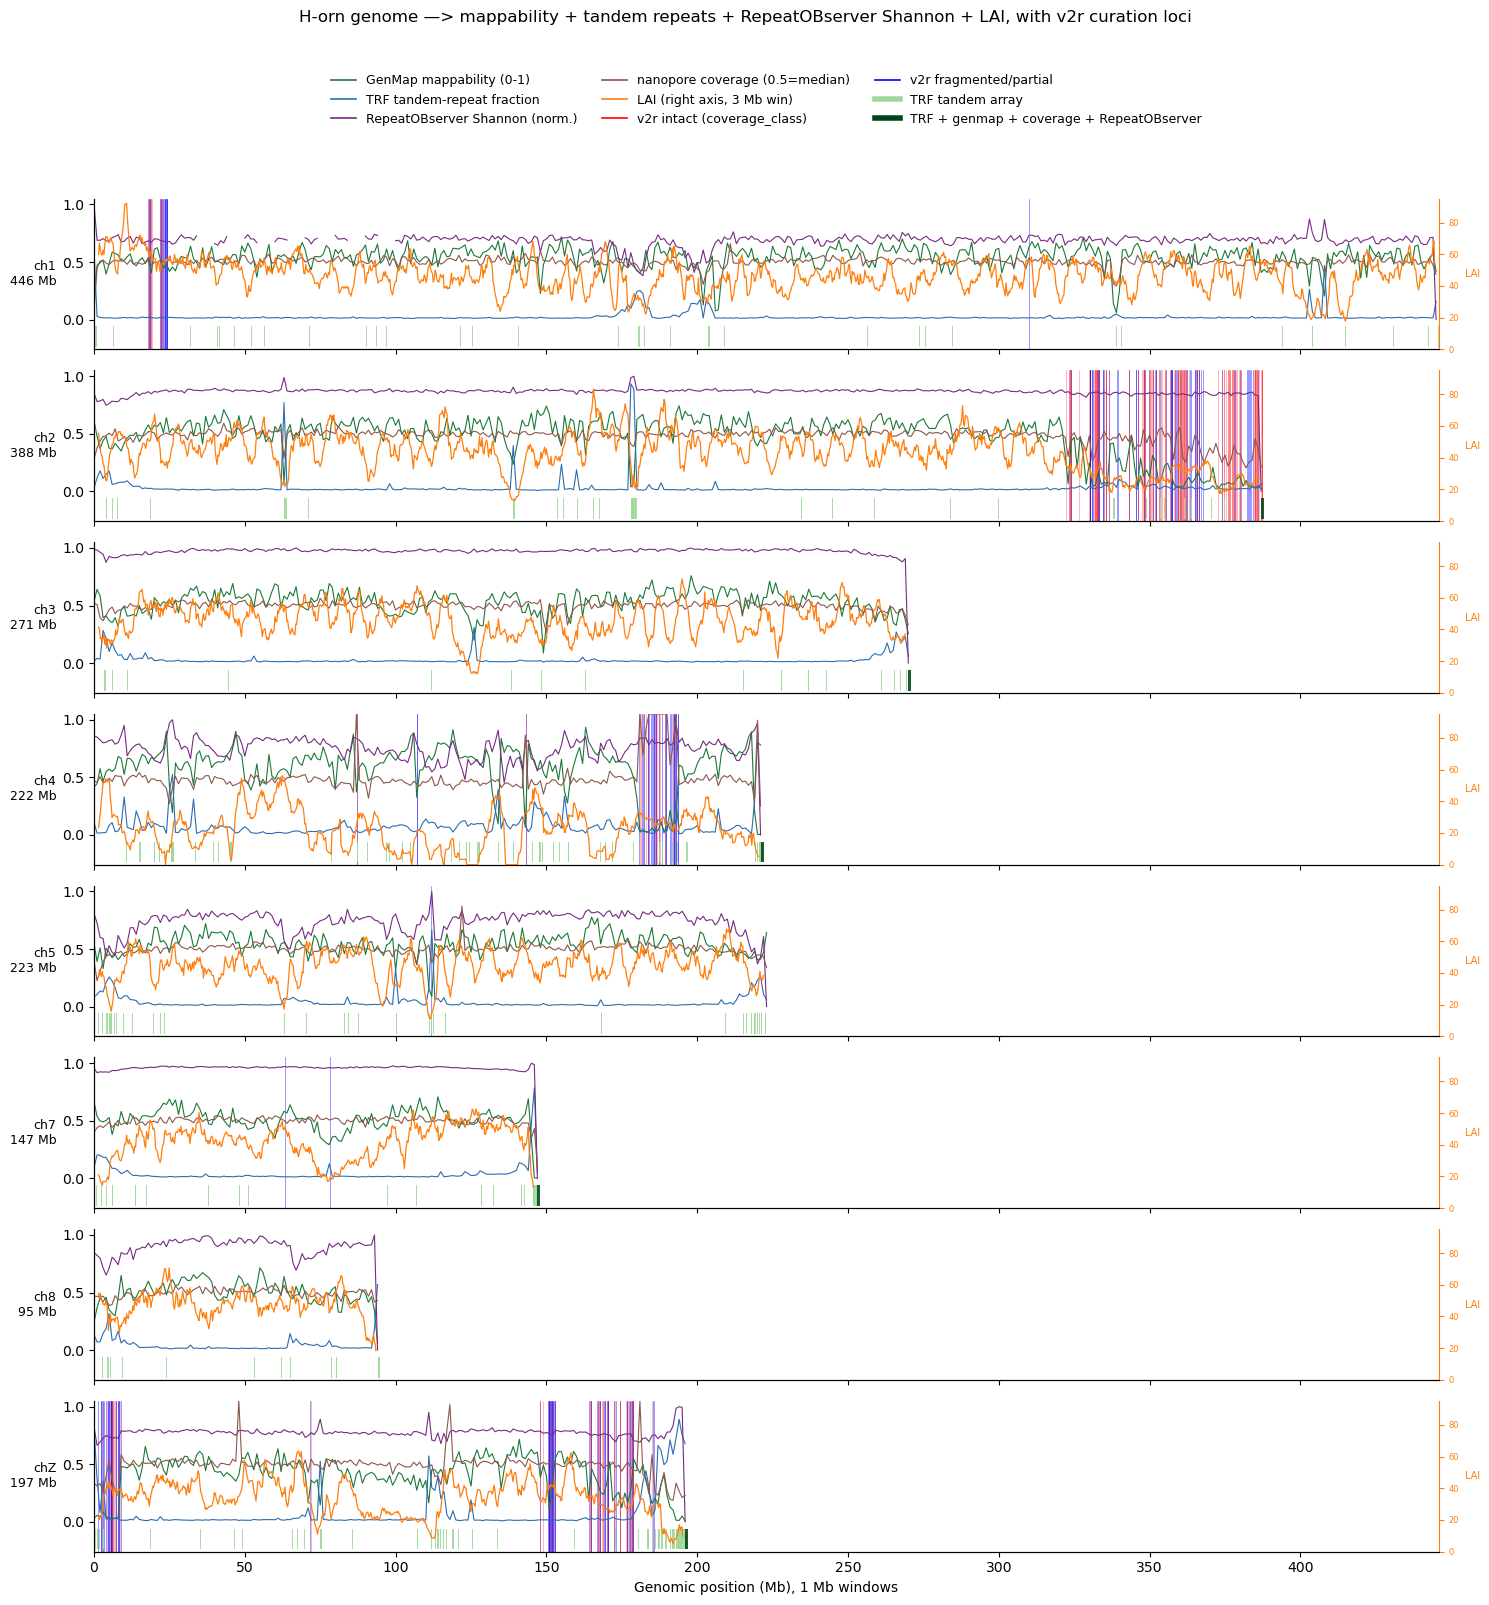

In [ ]:
fig, axes = plt.subplots(len(CHROMS), 1, figsize=(15, 2.0*len(CHROMS)), sharex=True)
for ax, c in zip(axes, CHROMS):
    x = np.arange(nbins[c])
    # v2r vertical hit markers (behind tracks)
    for px in v2r_other[c]:
        ax.axvline(px, color=BLUE, lw=0.4, alpha=0.7, zorder=0)
    for px in v2r_intact[c]:
        ax.axvline(px, color=RED, lw=0.4, alpha=0.5, zorder=1)
    # primary normalised tracks
    ax.plot(x, mapp[c],      color="#1b7837", lw=0.8, zorder=3)
    ax.plot(x, trf[c]/100.0, color="#2b6cb0", lw=0.8, zorder=3)
    ax.plot(x, norm(sha[c]), color="#762a83", lw=0.8, zorder=3)
    # coverage: depth/(2*median) so 0.5 = genome median depth, clipped to axis
    ax.plot(x, np.clip(cov[c]/(2*COV_MED), 0, 1.05), color="#8c564b", lw=0.8, zorder=3)
    plot_ta_track(ax, ta_display[c])
    plot_ta_track(ax, ta_strong_display[c], color=TA_STRONG_COLOR, alpha=0.88, zorder=15)
    ax.set_xlim(0, maxb); ax.set_ylim(min(TA_YBOT - 0.02, -0.05), 1.05)
    ax.set_ylabel(f"{c}\n{length[c]/1e6:.0f} Mb", rotation=0, ha="right", va="center", fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
    # LAI on twin axis (real units)
    ax2 = ax.twinx()
    if lai_x[c]:
        ax2.plot(lai_x[c], lai_y[c], color="#ff7f0e", lw=0.9, zorder=2)
    ax2.set_ylim(0, LAI_MAX); ax2.set_xlim(0, maxb)
    ax2.set_ylabel("LAI", rotation=0, ha="left", va="center", fontsize=7, color="#ff7f0e")
    ax2.tick_params(axis="y", labelsize=6, colors="#ff7f0e")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_color("#ff7f0e")

axes[-1].xaxis.set_major_formatter(FuncFormatter(mb))
axes[-1].set_xlabel("Genomic position (Mb), 1 Mb windows")

legend_handles = [
    Line2D([0],[0], color="#1b7837", lw=1.2, label="GenMap mappability (0-1)"),
    Line2D([0],[0], color="#2b6cb0", lw=1.2, label="TRF tandem-repeat fraction"),
    Line2D([0],[0], color="#762a83", lw=1.2, label="RepeatOBserver Shannon (norm.)"),
    Line2D([0],[0], color="#8c564b", lw=1.2, label="nanopore coverage (0.5=median)"),
    Line2D([0],[0], color="#ff7f0e", lw=1.2, label="LAI (right axis, 3 Mb win)"),
    Line2D([0],[0], color=RED,  lw=1.2, label="v2r intact (coverage_class)"),
    Line2D([0],[0], color=BLUE, lw=1.2, label="v2r fragmented/partial"),
    Line2D([0],[0], color=TA_COLOR, lw=4, label="TRF tandem array"),
    Line2D([0],[0], color=TA_STRONG_COLOR, lw=4, label="TRF + genmap + coverage + RepeatOBserver"),
]
axes[0].legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.9),
               ncol=3, fontsize=9, frameon=False)
fig.tight_layout(rect=[0,0,1,0.98])
out = "combined_mappability_TR_robserver_LAI_v2r.png"
fig.savefig(out, dpi=150)
print("wrote", out)
for c in CHROMS:
    print(f"  {c}: LAI windows={len(lai_x[c])}, intact={len(v2r_intact[c])}, fragmented/other={len(v2r_other[c])}")


## V2R tandem-signal analysis

1 Mb bin enrichment tests (ported from `v2r_tandem_signal_analysis.py`).

Uses the same paths as the mega-plot config cell (`BIN`, `CHROMS`, `FAI`, `TRF`, `MAP`, `SHA`, `LAI`, `V2R_GENES`, `COV`).

V2R groups from curation `coverage_class`:
- **intact** (red)
- **fragmented/partial** (blue)
- **any_v2r**

Outputs → `../v2r_tandem_signal_results/`.

In [27]:
# wire tandem-signal analysis to mega-plot paths
import importlib
import sys
from pathlib import Path

NB_DIR = Path("/hpcfs/users/a1864358/sanders_lab/asm/files/tandem-repeat-anal/genome-context")
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import v2r_tandem_signal_analysis as vts
importlib.reload(vts)

OUTDIR = Path("/hpcfs/users/a1864358/sanders_lab/asm/files/tandem-repeat-anal/v2r_tandem_signal_results")

# faster notebook defaults; bump for publication (10000 / 5000)
NPERM_BINARY = 2000
NPERM_METRIC = 1000

vts.configure(
    bin_size=BIN,
    chroms=CHROMS,
    fai=FAI,
    trf=TRF,
    map_path=MAP,
    sha=SHA,
    cov=COV,
    lai=LAI,
    v2r_genes=V2R_GENES,
    outdir=OUTDIR,
    nperm_binary=NPERM_BINARY,
    nperm_metric=NPERM_METRIC,
)

print("BIN", vts.BIN)
print("CHROMS", vts.CHROMS)
print("FAI", vts.FAI)
print("TRF", vts.TRF)
print("MAP", vts.MAP)
print("SHA", vts.SHA)
print("LAI", vts.LAI)
print("V2R_GENES", vts.V2R_GENES)
print("COV", vts.COV)
print("OUTDIR", vts.OUTDIR)
print("nperm", vts.NPERM_BINARY, vts.NPERM_METRIC)
for p, lab in [
    (vts.FAI, "FAI"), (vts.TRF, "TRF"), (vts.MAP, "MAP"), (vts.SHA, "SHA"),
    (vts.COV, "COV"), (vts.LAI, "LAI"), (vts.V2R_GENES, "V2R_GENES"),
]:
    assert Path(p).exists(), f"missing {lab}: {p}"
print("all inputs OK")

BIN 1000000
CHROMS ['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch7', 'ch8', 'chZ']
FAI /hpcfs/users/a1864358/sanders_lab/resources/final-asms/10-horn-final.renamed.fa.fai
TRF /hpcfs/users/a1864358/sanders_lab/asm/files/tandem-repeat-anal/genome-context/trf_horn/horn.trf.ngs.dat
MAP /hpcfs/users/a1864358/sanders_lab/asm/files/repeat-anno/ra2/results/07_comparative/genmap/horn/mappability.1Mb.tsv
SHA /hpcfs/users/a1864358/sanders_lab/asm/files/tandem-repeat-anal/robserver_horn_shannon.tsv
LAI /hpcfs/users/a1864358/sanders_lab/asm/files/repeat-anno/ra2/results/05_LAI/final/10-horn-final.renamed.fa.hybridlib.out.LAI
V2R_GENES /hpcfs/users/a1864358/sanders_lab/asm/files/annotation/eviann_results/hmaj/curation/results/horn/v2r_genes.tsv
COV /hpcfs/users/a1864358/sanders_lab/asm/files/tandem-repeat-anal/horn_cov.1Mb.tsv
OUTDIR /hpcfs/users/a1864358/sanders_lab/asm/files/tandem-repeat-anal/v2r_tandem_signal_results
nperm 2000 1000
all inputs OK


In [28]:
# build 1 Mb bin table + V2R counts (intact / fragmented-partial / any)
ts_df, ts_cov_med = vts.build_bin_table()
print(f"bins={len(ts_df)}  cov_median={ts_cov_med:.3f}")
print(ts_df[["v2r_intact_bin", "v2r_other_bin", "v2r_any_bin"]].sum())
print(ts_df.groupby("chrom")[["v2r_intact_count", "v2r_other_count", "v2r_any_count"]].sum())
ts_df.head()

bins=1991  cov_median=57.664
v2r_intact_bin     80
v2r_other_bin      82
v2r_any_bin       103
dtype: int64
       v2r_intact_count  v2r_other_count  v2r_any_count
chrom                                                  
ch1                  10               19             29
ch2                 121               68            189
ch3                   0                0              0
ch4                  15               35             50
ch5                   0                1              1
ch7                   0                2              2
ch8                   0                0              0
chZ                  44               70            114


,chrom,bin,start,end,width,mappability,coverage,coverage_ratio,coverage_absdev,shannon,...,v2r_other_count,v2r_any_count,v2r_intact_bin,v2r_other_bin,v2r_any_bin,dist_to_v2r_bin,strong_tandem_signature,trf_bin,low_map_bin,coverage_anomaly_bin
0,ch1,0,1,1000000,1000000,0.084720,20.1129,0.348795,0.651205,6.338635,...,0,0,False,False,False,18.0,False,True,True,True
1,ch1,1,1000001,2000000,1000000,0.446628,54.5218,0.945508,0.054492,6.086102,...,0,0,False,False,False,17.0,False,True,True,False
2,ch1,2,2000001,3000000,1000000,0.508104,56.7303,0.983808,0.016192,6.085626,...,0,0,False,False,False,16.0,False,True,False,False
3,ch1,3,3000001,4000000,1000000,0.513092,59.7664,1.036459,0.036459,6.097355,...,0,0,False,False,False,15.0,False,True,False,False
4,ch1,4,4000001,5000000,1000000,0.394833,56.6908,0.983123,0.016877,6.081931,...,0,0,False,False,False,14.0,False,True,True,False


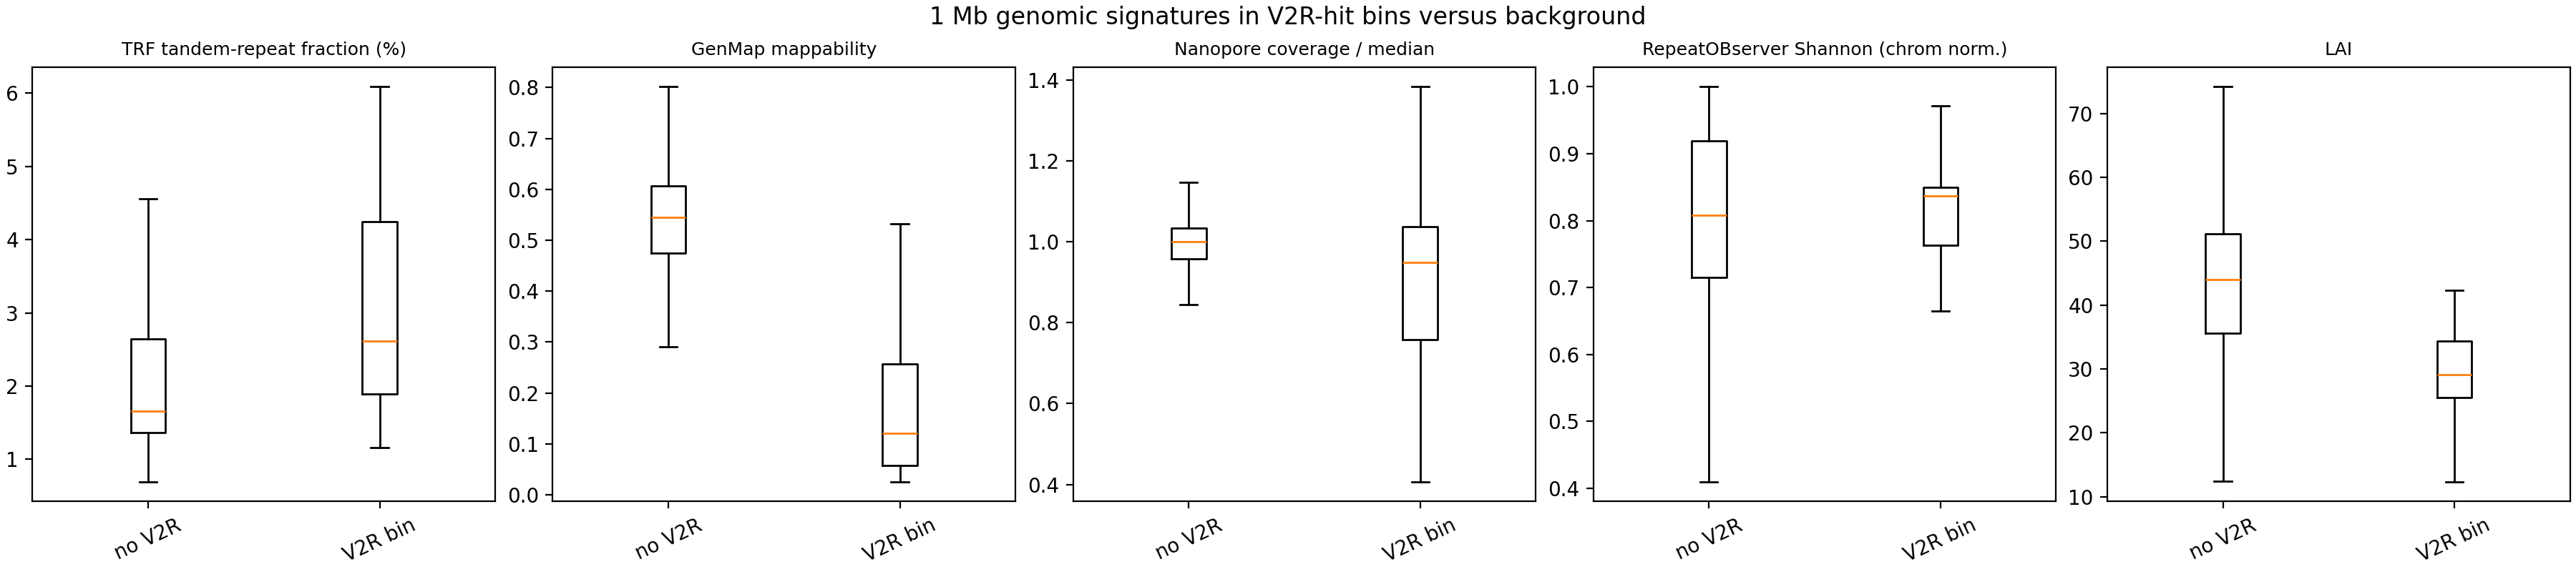

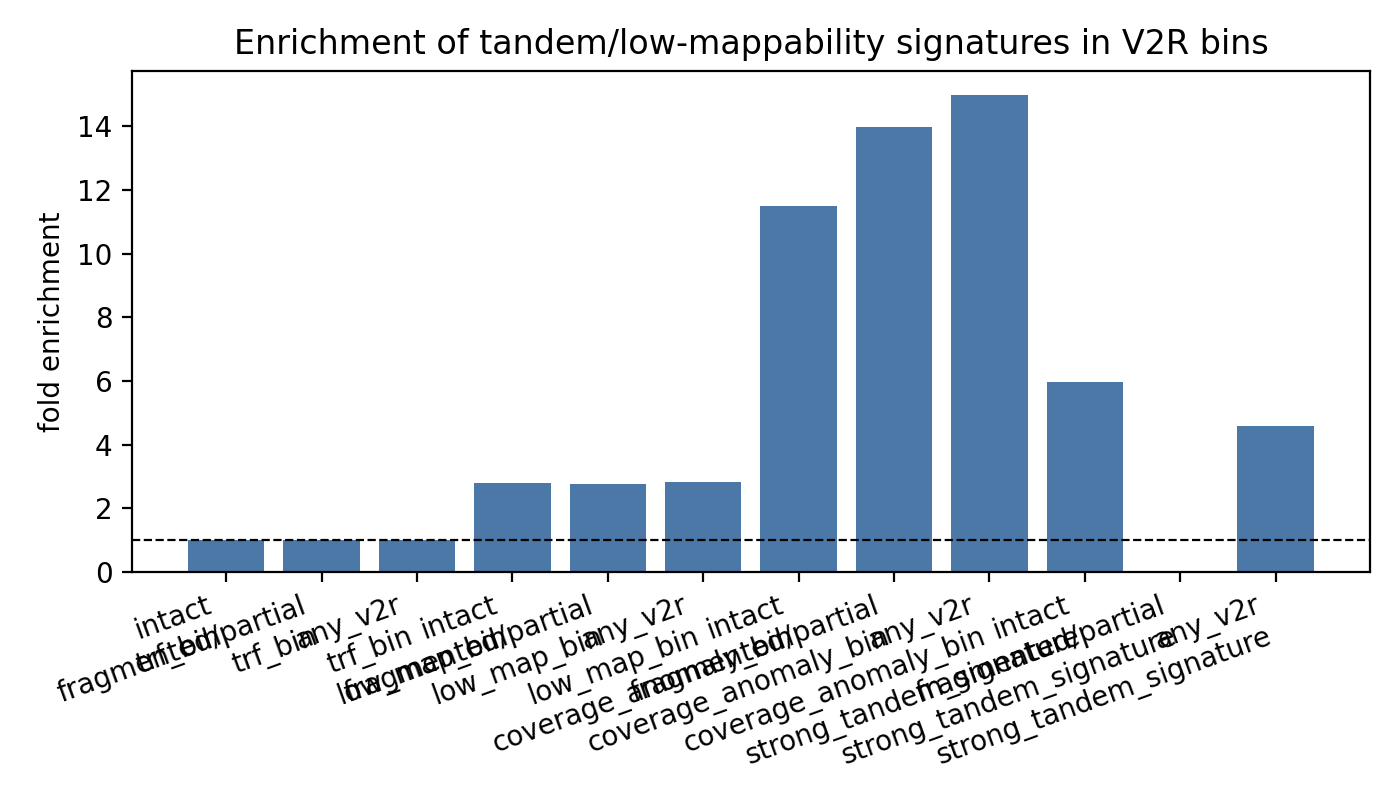

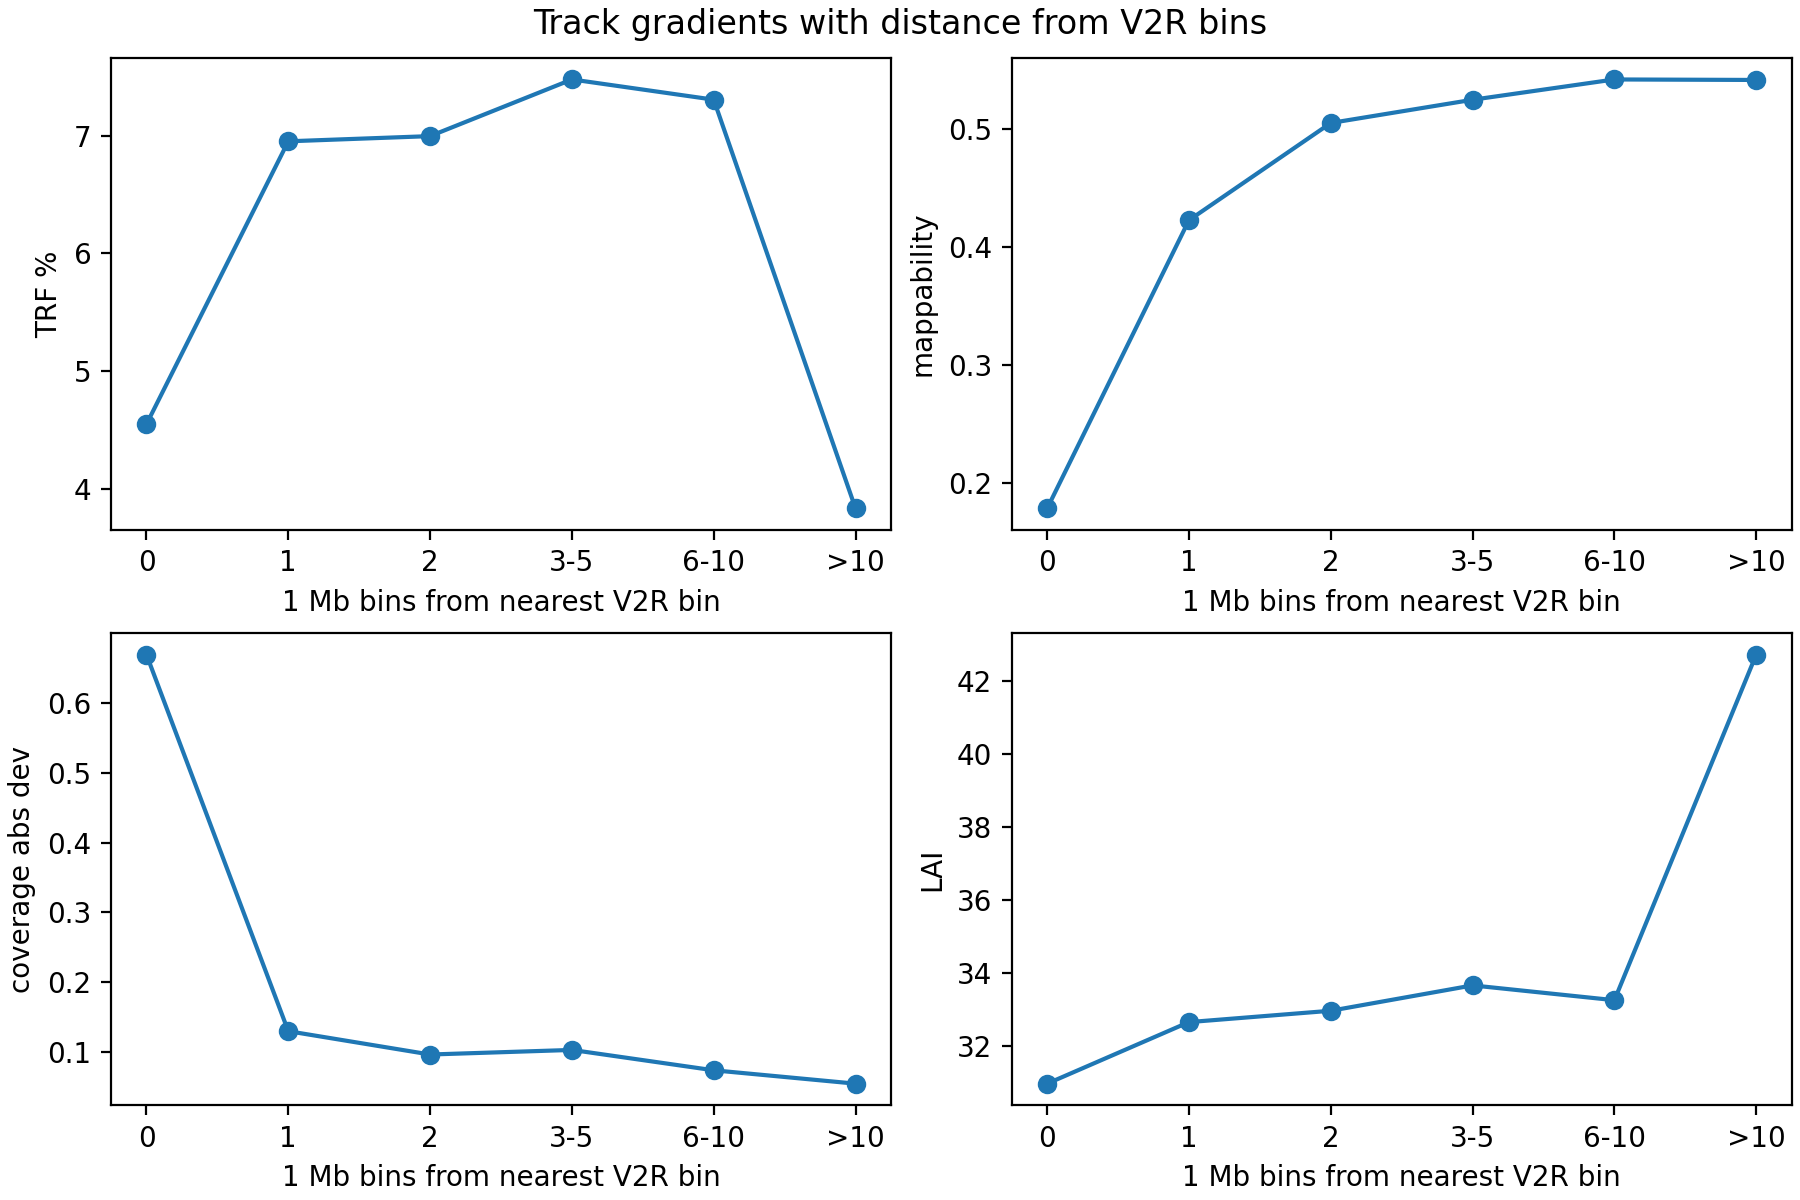

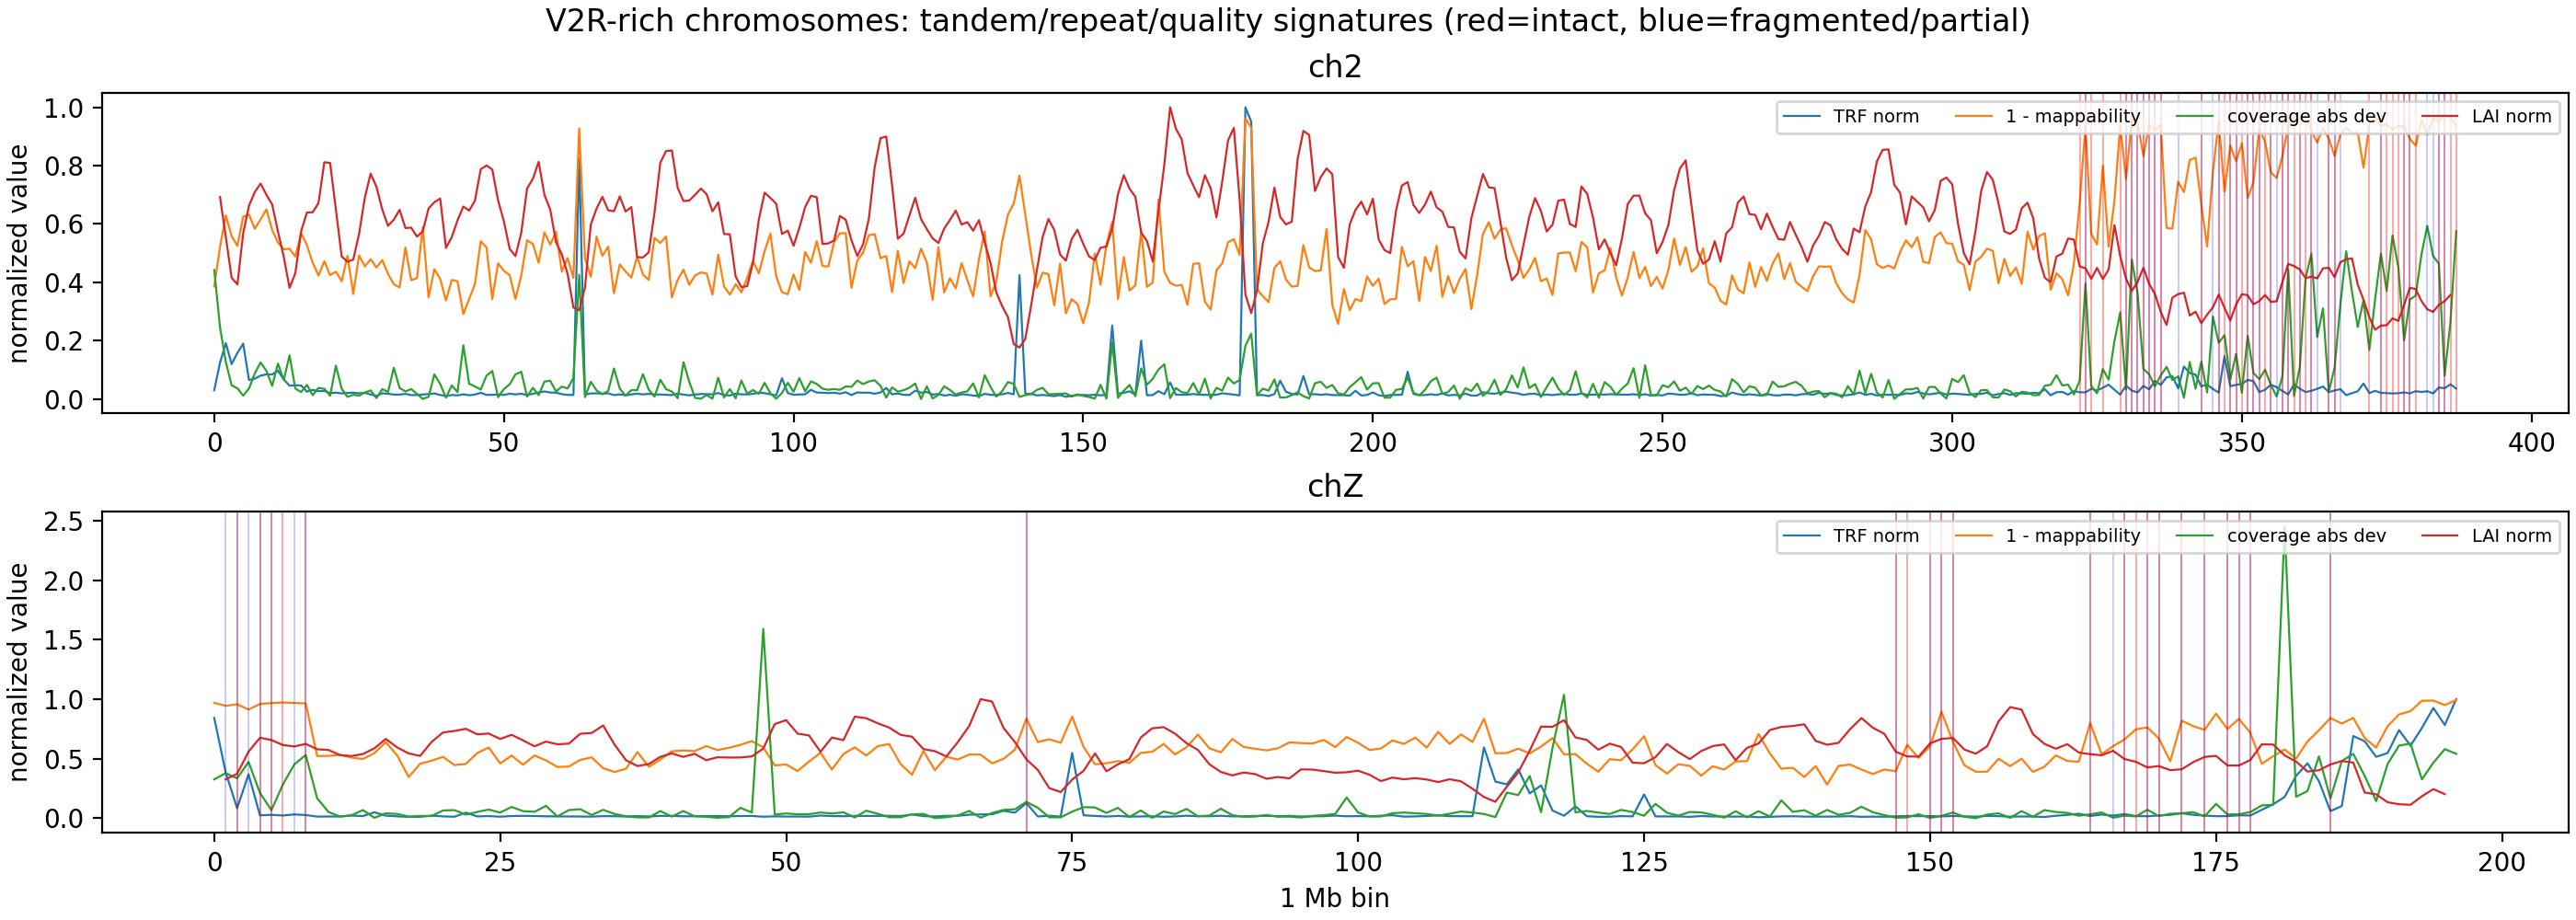

wrote /hpcfs/users/a1864358/sanders_lab/asm/files/tandem-repeat-anal/v2r_tandem_signal_results
chrom  n_bins  v2r_any_bins  intact_bins  other_bins  mean_trf_pct  mean_mappability  mean_coverage_absdev  mean_lai  strong_signature_bins
  ch1     446             7            4           5      2.427485          0.538610              0.046392 46.786338                      0
  ch2     388            50           43          34      3.138153          0.477822              0.072967 43.592332                      1
  ch3     271             0            0           0      2.782447          0.532059              0.048880 45.580081                      1
  ch4     222            17           11          17      7.902246          0.587917              0.320648 22.214462                      1
  ch5     224             1            0           1      3.953851          0.542324              0.058524 44.493141                      0
  ch7     148             2            0           2      4.62794

,v2r_group,signature,n_v2r_bins,n_background_bins,v2r_signature_bins,background_signature_bins,v2r_fraction,background_fraction,fold,chrom_matched_perm_p_enrichment,chrom_matched_q_bh
8,any_v2r,coverage_anomaly_bin,103,1888,36,44,0.349515,0.023305,14.997352,0.000500,0.001000
7,fragmented/partial,coverage_anomaly_bin,82,1909,30,50,0.365854,0.026192,13.968293,0.000500,0.001000
6,intact,coverage_anomaly_bin,80,1911,26,54,0.325000,0.028257,11.501389,0.000500,0.001000
9,intact,strong_tandem_signature,80,1911,1,4,0.012500,0.002093,5.971875,0.269365,0.323238
11,any_v2r,strong_tandem_signature,103,1888,1,4,0.009709,0.002119,4.582524,0.320840,0.350007
5,any_v2r,low_map_bin,103,1888,97,631,0.941748,0.334216,2.817780,0.000500,0.001000
3,intact,low_map_bin,80,1911,76,652,0.950000,0.341183,2.784433,0.000500,0.001000
4,fragmented/partial,low_map_bin,82,1909,77,651,0.939024,0.341016,2.753606,0.000500,0.001000
2,any_v2r,trf_bin,103,1888,103,1851,1.000000,0.980403,1.019989,0.147926,0.253587
1,fragmented/partial,trf_bin,82,1909,82,1872,1.000000,0.980618,1.019765,0.256872,0.323238


,v2r_group,metric,n_v2r_bins,n_background_bins,mean_v2r,mean_background,median_v2r,median_background,mean_difference,perm_p_two_sided,chrom_matched_mean_difference,chrom_matched_perm_p_two_sided,q_bh,chrom_matched_q_bh
1,intact,mappability,80,1911,0.165943,0.530181,0.108010,0.543959,-0.364238,0.000999,-0.364238,0.000999,0.002098,0.001907
4,intact,shannon,80,1876,6.015078,6.058000,6.037475,6.082557,-0.042922,0.038961,-0.042922,0.000999,0.062937,0.001907
6,intact,lai,79,1894,30.779346,41.865638,29.180000,43.958333,-11.086292,0.000999,-11.086292,0.000999,0.002098,0.001907
15,any_v2r,mappability,103,1888,0.178213,0.533949,0.120941,0.544931,-0.355736,0.000999,-0.355736,0.000999,0.002098,0.001907
13,fragmented/partial,lai,82,1891,30.845488,41.880357,28.771667,43.956667,-11.034870,0.000999,-11.034870,0.000999,0.002098,0.001907
10,fragmented/partial,coverage_absdev,82,1909,0.786683,0.061492,0.124090,0.038313,0.725191,0.000999,0.725191,0.000999,0.002098,0.001907
9,fragmented/partial,coverage_ratio,82,1909,1.540305,0.987355,0.971647,1.000411,0.552950,0.000999,0.552950,0.000999,0.002098,0.001907
8,fragmented/partial,mappability,82,1909,0.177376,0.530072,0.126075,0.543963,-0.352695,0.000999,-0.352695,0.000999,0.002098,0.001907
17,any_v2r,coverage_absdev,103,1888,0.668982,0.059847,0.127896,0.038054,0.609135,0.000999,0.609135,0.000999,0.002098,0.001907
20,any_v2r,lai,102,1871,30.964861,41.991807,29.085000,44.006667,-11.026945,0.000999,-11.026945,0.000999,0.002098,0.001907


In [29]:
# enrichment + metric-shift permutation tests + plots
ts_results = vts.run_analysis(show_plots=True)
ts_enrich = ts_results["enrich"]
ts_shifts = ts_results["shifts"]
ts_chrom = ts_results["chrom_summary"]
display(ts_enrich.sort_values("fold", ascending=False).head(12))
display(ts_shifts.sort_values("chrom_matched_perm_p_two_sided").head(12))

### notes / to do
- bump `NPERM_BINARY`/`NPERM_METRIC` for final figures
- ch2 + chZ landscape already in tandem-signal track plot
- optional: overlay new vs old LAI on a separate plot